## 1. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.common import config
from src.common import data_loader, preprocessor, feature_engineering, labeling
from src.common import walk_forward, backtester, metrics, visualization
from src.strategies.ml_strategy import quantile_positions
from src.models.svm_poly.model import PolynomialSVMModel
from src.common.tuning import TunedModel
from src.models.svm_poly.config import PARAM_GRID

np.random.seed(config.RANDOM_SEED)

MARKET = "FTSE100"
MODEL_NAME = "svm_poly"
print(f"Market: {MARKET} | Period: {config.START_DATE} -> {config.END_DATE}")
print(f"Inner-tuning grid: {PARAM_GRID}")

Market: FTSE100 | Period: 2006-05-16 -> 2026-05-11
Inner-tuning grid: {'C': [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], 'degree': [1, 2, 3]}


## 2. Data

In [2]:
raw = preprocessor.clean(data_loader.download_index(MARKET))
X = feature_engineering.build_paper_feature_matrix(raw, wpr_window=15) # Using best config
y = labeling.next_day_return(raw, horizon=1)
common = X.index.intersection(y.index)
X = X.loc[common]
y = y.loc[common]
fwd_ret = y.copy()  # for the backtester / hit-rate
print(f"Features ({len(X.columns)}): {list(X.columns)}")
print(f"Observations: {len(X)}  ({X.index.min().date()} -> {X.index.max().date()})")
print(f"Target (next-day return) std: {y.std():.4f}")

Features (7): ['sma_signal_15', 'macd_hist', 'stoch_k_14', 'stoch_d_3', 'stoch_slow_d_3', 'rsi_14', 'willr_15']
Observations: 5028  (2006-06-09 -> 2026-05-06)
Target (next-day return) std: 0.0111


## 3. Walk-forward Validation

In [3]:
trimmed_index = walk_forward.trim_to_full_folds(
    X.index, train_window=config.TRAIN_WINDOW, step=config.STEP,
)
X_wf, y_wf, fwd_wf = X.loc[trimmed_index], y.loc[trimmed_index], fwd_ret.loc[trimmed_index]
total_folds = (len(trimmed_index) - config.TRAIN_WINDOW) // config.STEP
print(f"Trimmed {len(X) - len(trimmed_index)} leading rows | {total_folds} folds of {config.TRAIN_WINDOW}/{config.TEST_WINDOW}d")
print(f"Validation hold-out size: 20 days  |  inner-train size: {config.TRAIN_WINDOW - 20} days")
print(f"Inner-tuning grid: {PARAM_GRID}")

oos_score = []
best_params_log: list[dict] = []
for fold, (train_idx, test_idx) in enumerate(
    walk_forward.rolling_splits(
        index=X_wf.index,
        train_window=config.TRAIN_WINDOW,
        test_window=config.TEST_WINDOW,
        step=config.STEP,
    )
):
    model = TunedModel(
        PolynomialSVMModel,
        param_grid=PARAM_GRID,
        val_size=20,
        scoring="neg_mse",
    )
    model.fit(X_wf.loc[train_idx], y_wf.loc[train_idx])
    best_params_log.append({"fold": fold, **model.best_params_, "val_score": model.best_score_})
    oos_score.append(model.predict_score(X_wf.loc[test_idx]))
    if fold % 20 == 0 or fold == total_folds - 1:
        print(f"  fold {fold:>3d}/{total_folds-1}: best={model.best_params_} (val score {model.best_score_:+.6f})")

oos_score = pd.concat(oos_score).sort_index()
print(f"\nTotal out-of-sample observations: {len(oos_score)}")

best_params_df = pd.DataFrame(best_params_log)
print("\nBest-param frequency across folds:")
print(best_params_df.drop(columns=["fold", "val_score"]).value_counts().head(10))

Trimmed 8 leading rows | 241 folds of 200/20d
Validation hold-out size: 20 days  |  inner-train size: 180 days
Inner-tuning grid: {'C': [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], 'degree': [1, 2, 3]}
  fold   0/240: best={'C': 1.0, 'degree': 1} (val score -0.000093)
  fold  20/240: best={'C': 0.5, 'degree': 1} (val score -0.002428)
  fold  40/240: best={'C': 1.0, 'degree': 1} (val score -0.000429)
  fold  60/240: best={'C': 0.5, 'degree': 2} (val score -0.000123)
  fold  80/240: best={'C': 1.0, 'degree': 1} (val score -0.000026)
  fold 100/240: best={'C': 1.0, 'degree': 2} (val score -0.000015)
  fold 120/240: best={'C': 0.1, 'degree': 1} (val score -0.000066)
  fold 140/240: best={'C': 0.7, 'degree': 1} (val score -0.000035)
  fold 160/240: best={'C': 0.2, 'degree': 1} (val score -0.000028)
  fold 180/240: best={'C': 0.3, 'degree': 1} (val score -0.000046)
  fold 200/240: best={'C': 0.05, 'degree': 1} (val score -0.000028)
  fold 220/240: best={'C': 0.9, 'degree': 1} (v

## 4. Strategy & 5. Backtest

In [4]:
positions = quantile_positions(oos_score, q_low=0.4, q_high=0.6, mode='long_short')
fwd_oos = fwd_wf.loc[positions.index]

ml_bt = backtester.backtest(positions, fwd_oos)
bh_bt = backtester.buy_and_hold_backtest(fwd_oos)
print(f"Signal balance: +1={int((positions==1).sum())}  0={int((positions==0).sum())}  -1={int((positions==-1).sum())}")
ml_bt.tail()

Signal balance: +1=1928  0=964  -1=1928


,position,gross_return,equity
date,,,
2026-04-29,1.0,0.016224,6.100724
2026-04-30,1.0,-0.001436,6.091966
2026-05-01,1.0,-0.013972,6.006851
2026-05-05,1.0,0.021489,6.135933
2026-05-06,1.0,-0.015490,6.040885


## 6. Metrics

In [5]:
summary = pd.DataFrame({
    f"{MODEL_NAME}": metrics.summary(
        ml_bt["gross_return"], ml_bt["equity"], positions, fwd_oos,
    ),
    "buy_and_hold": metrics.summary(
        bh_bt["gross_return"], bh_bt["equity"],
        pd.Series(1.0, index=fwd_oos.index), fwd_oos,
    ),
}).T

summary.to_csv(config.TABLES_DIR / f"{MARKET}_{MODEL_NAME}.csv")
summary.style.format("{:.4f}")

,CAGR,ARC,ASD,Sharpe,aSharpe,IR,IR_star,MDD,Calmar,Sortino,HitRate
svm_poly,0.0986,0.0986,0.1644,0.6542,0.5998,0.5998,0.2257,0.2620,0.3763,0.9770,0.5244
buy_and_hold,0.0254,0.0254,0.1791,0.2295,0.1416,0.1415,0.0075,0.4783,0.0530,0.2212,0.5243


## 7. Plots

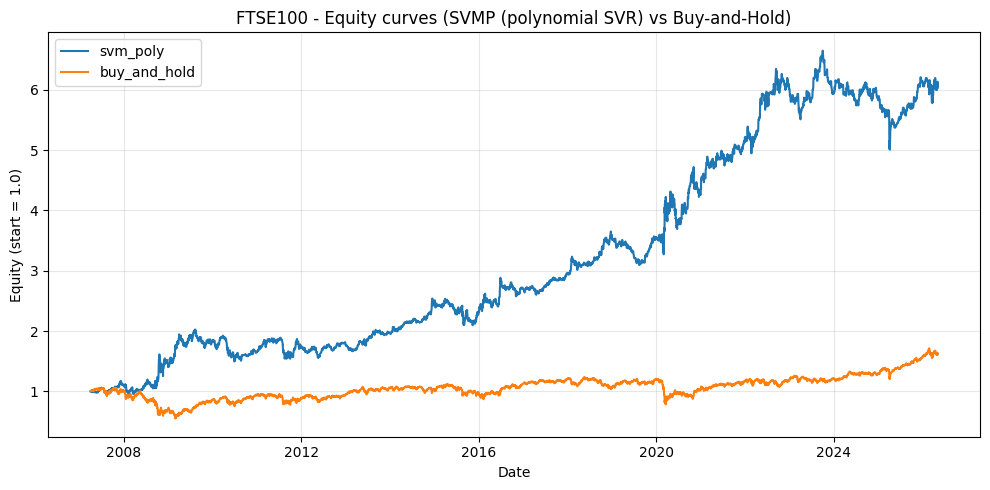

In [6]:
fig_eq = visualization.plot_equity_curve(
    {f"{MODEL_NAME}": ml_bt["equity"], "buy_and_hold": bh_bt["equity"]},
    title=f"{MARKET} - Equity curves (SVMP (polynomial SVR) vs Buy-and-Hold)",
)
fig_eq.savefig(config.FIGURES_DIR / f"{MARKET}_{MODEL_NAME}_equity.png", dpi=150)
plt.show()

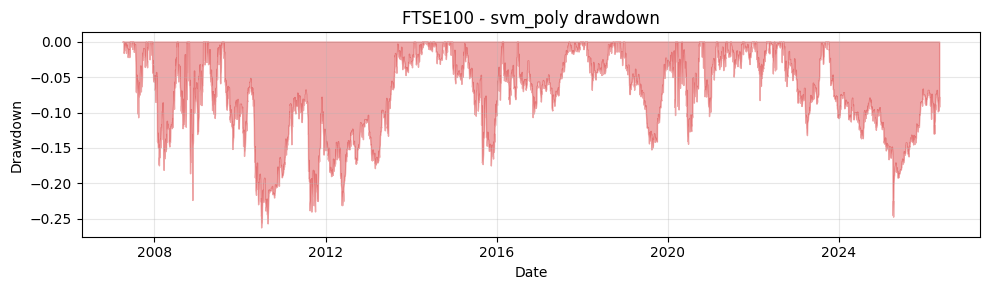

In [7]:
fig_dd = visualization.plot_drawdown(ml_bt["equity"], title=f"{MARKET} - {MODEL_NAME} drawdown")
fig_dd.savefig(config.FIGURES_DIR / f"{MARKET}_{MODEL_NAME}_drawdown.png", dpi=150)
plt.show()